
---
date: "2026-08-16"
date-modified: last-modified
format:
  html:
    toc: true
---


# Stochastic Modeling in Finance: Microstructure, Credit Migration, and Regimes

Modern quantitative finance relies fundamentally on [stochastic processes](stochastic-processes-foundations.ipynb) to model asset prices, high-frequency order flows, credit risk migrations, and macroeconomic regime shifts. While classical deterministic models fail to capture the pervasive uncertainty of market environments, stochastic calculus provides rigorous tools to quantify risk and price complex financial derivatives.

This node bridges foundational stochastic process theory with core financial applications: from the landmark **Black-Scholes-Merton** continuous-time framework to discrete-state **credit rating Markov chains**, **market microstructure point processes**, and **regime-switching diffusions**.

---


## 1\. Motivation: Derivative Pricing and Geometric Brownian Motion

A central motivation for developing stochastic calculus was the pricing and hedging of **financial derivatives** (options, futures, and fixed-income contracts), culminating in the 1997 Nobel Prize in Economics awarded to Robert C. Merton and Myron Scholes (with Fischer Black posthumously recognized).

::: {#def-geometric-brownian-motion}
## Geometric Brownian Motion (GBM)
Let $(W_t)_{t \ge 0}$ be a standard [Brownian motion](gaussian-processes.ipynb) on $(\Omega, \mathcal{F}, \mathbb{P})$. An asset price process $(S_t)_{t \ge 0}$ follows **Geometric Brownian Motion** with drift $\mu \in \mathbb{R}$ and volatility $\sigma > 0$ if it satisfies the stochastic differential equation (SDE):
$$
dS_t = \mu S_t \, dt + \sigma S_t \, dW_t, \quad S_0 > 0
$$
The exact analytical solution of this SDE is given by:
$$
S_t = S_0 \exp\left( \left( \mu - \frac{1}{2}\sigma^2 \right)t + \sigma W_t \right)
$$
:::

::: {.callout-note}
## Intuition: The Necessity of Itô Calculus and the $-\frac{1}{2}\sigma^2$ Correction
In classical ordinary differential calculus, solving $\frac{dS_t}{S_t} = \mu dt$ yields $S_t = S_0 e^{\mu t}$. When adding the stochastic differential term $\sigma dW_t$, ordinary chain rule calculus would naively predict $S_0 e^{\mu t + \sigma W_t}$. 

However, because Brownian sample paths have non-zero **quadratic variation** $(dW_t)^2 = dt$, Taylor expansions of smooth functions $f(W_t)$ cannot truncate second-order increments. Applying **Itô's Lemma** to $f(x) = \ln x$ produces the essential correction term $-\frac{1}{2}\sigma^2 t$, guaranteeing that the expected asset price correctly satisfies $\mathbb{E}[S_t] = S_0 e^{\mu t}$.
:::


## 2\. Market Microstructure: Point Processes and Order Flow

At microscopic time scales (milliseconds to seconds), financial markets do not behave as continuous diffusions. Instead, markets operate as discrete double auction mechanisms governed by high-frequency order books.

Key microstructure questions include:
1. **Arrival Timing:** When do new market or limit orders arrive?
2. **Quote Placement:** At what bid/ask limit prices are orders posted?
3. **Execution & Matching:** At what transaction prices are buy and sell orders cleared?

::: {#def-poisson-order-process}
## Poisson Counting Process for Order Arrivals
Let $(\tau_k)_{k=1}^\infty$ be a sequence of strictly increasing random order arrival times. The order counting process $(N_t)_{t \ge 0}$ defined by:
$$
N_t = \sum_{k=1}^\infty \mathbf{1}_{\{ \tau_k \le t \}}
$$
is a homogeneous **[Poisson process](poisson-distribution.ipynb)** with intensity $\lambda > 0$ if:
1. $N_0 = 0$ almost surely.
2. The process has independent increments.
3. For any $s < t$, $N_t - N_s \sim \text{Poisson}(\lambda(t - s))$ with probability mass function:
$$
\mathbb{P}(N_t - N_s = k) = \frac{(\lambda(t - s))^k e^{-\lambda(t - s)}}{k!}, \quad k = 0, 1, 2, \dots
$$
:::

::: {#def-marked-point-process}
## Marked Point Process
In full market microstructure models, each order arrival $\tau_k$ carries random marks $(V_k, P_k, D_k)$, where $V_k$ is the order volume, $P_k$ is the limit price, and $D_k \in \{\text{Buy}, \text{Sell}\}$ is the trade direction. The resulting order flow is a **marked point process** $(\tau_k, \mathbf{M}_k)_{k \ge 1}$.
:::


## 3\. Discrete State Spaces: Credit Rating Migration Models

In credit risk management, corporate debt obligors are assigned credit quality ratings by agencies (e.g., Moody's, S&P). Rating migrations occur across discrete categories, ending in bankruptcy or default.

::: {#def-credit-rating-chain}
## Credit Rating Markov Chain
Let the discrete state space be $\mathcal{S} = \{1, 2, \dots, K\}$, representing ordered rating grades from highest creditworthiness to default (e.g., $\{AAA, AA, A, BBB, BB, B, CCC, D\}$ with $K = 8$). 

The migration process $(C_t)_{t \in \mathbb{N}_0}$ is a discrete-time **Markov chain** with transition probability matrix $\mathbf{P} = (p_{ij})_{i,j=1}^K$, where:
$$
p_{ij} = \mathbb{P}\left( C_{t+1} = j \mid C_t = i \right), \quad \sum_{j=1}^K p_{ij} = 1, \quad \forall i
$$
State $K$ (Default, $D$) is an **absorbing state**, meaning $p_{KK} = 1$ and $p_{Kj} = 0$ for all $j < K$.
:::

::: {.callout-tip collapse="true"}
## Multi-Period Transition and Cumulative Default Probabilities
By the Chapman-Kolmogorov equations, the $n$-step transition probability matrix $\mathbf{P}^{(n)}$ is the $n$-th matrix power of $\mathbf{P}$:
$$
\mathbf{P}^{(n)} = \mathbf{P}^n
$$
For an obligor initially holding rating $i$ at $t = 0$, the cumulative probability of default over an $n$-year horizon is given directly by the $(i, K)$-th entry of $\mathbf{P}^n$:
$$
\text{PD}_i(n) = \mathbb{P}\left( C_n = K \mid C_0 = i \right) = \left[ \mathbf{P}^n \right]_{i, K} \quad \blacksquare
$$
:::


## 4\. Regime-Switching Diffusions: Macroeconomic Regimes

Empirical financial time series frequently display abrupt structural breaks caused by shifting macroeconomic regimes:
- **Market Direction:** Bullish (upward drift) vs. Bearish (downward drift).
- **Market Volatility:** Low-volatility calm regimes vs. High-volatility crisis periods.

::: {#def-regime-switching-diffusion}
## Regime-Switching Diffusion
Let $(S_t)_{t \ge 0}$ be a continuous-time Markov chain taking values in a finite regime space $\mathcal{M} = \{1, 2, \dots, M\}$ with generator matrix $\mathbf{Q} = (q_{ij})$. A **regime-switching diffusion** $(X_t)_{t \ge 0}$ evolves according to:
$$
dX_t = \mu(S_t) \, dt + \sigma(S_t) \, dW_t
$$
where $\mu(k)$ and $\sigma(k)$ are regime-dependent drift and volatility parameters for regime $k \in \mathcal{M}$, and $(W_t)_{t \ge 0}$ is a standard Brownian motion independent of $(S_t)_{t \ge 0}$.
:::

::: {.callout-warning}
## Non-Gaussianity and Heavy Tails
While conditionally Gaussian given the state trajectory $(S_t)_{t \ge 0}$, the unconditional marginal distribution of a regime-switching process is a **continuous mixture of Gaussians**. This mixture naturally produces **fat tails (excess kurtosis)** and volatility clustering, matching stylized empirical facts of financial asset returns.
:::


## 5\. Python Simulation: Microstructure, Credit Migration, and Regime-Switching

Below, we simulate high-frequency Poisson order flows, credit rating transition trajectories across ratings AAA through D, and a 2-state regime-switching Geometric Brownian Motion.

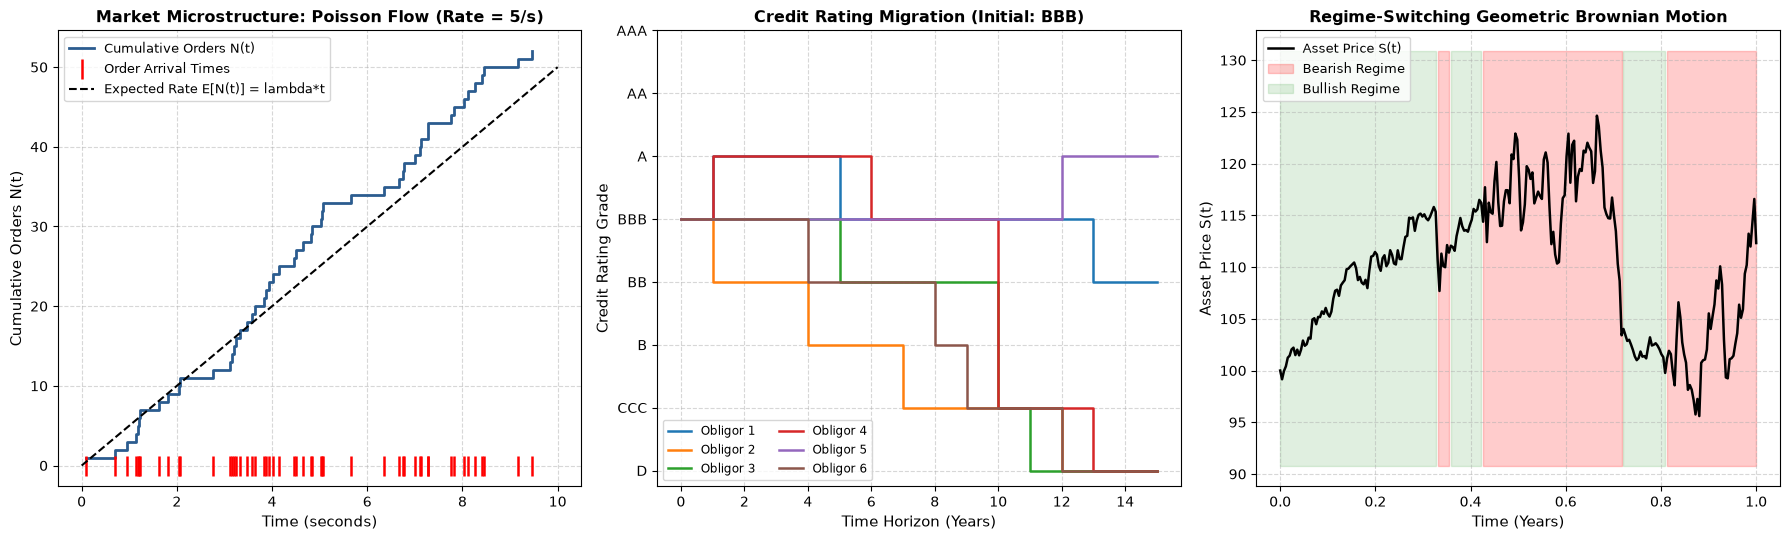

In [1]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# 1. Market Microstructure: Poisson Order Arrivals
lambda_rate = 5.0
T_total = 10.0
inter_arrivals = np.random.exponential(1.0 / lambda_rate, size=100)
arrival_times = np.cumsum(inter_arrivals)
arrival_times = arrival_times[arrival_times <= T_total]
order_counts = np.arange(1, len(arrival_times) + 1)

axes[0].step(arrival_times, order_counts, where='post', color='#2b5c8f', lw=2.0, label='Cumulative Orders N(t)')
axes[0].plot(arrival_times, np.zeros_like(arrival_times), 'r|', ms=14, mew=1.8, label='Order Arrival Times')
axes[0].plot([0, T_total], [0, lambda_rate * T_total], 'k--', lw=1.5, label='Expected Rate E[N(t)] = lambda*t')
axes[0].set_title('Market Microstructure: Poisson Flow (Rate = 5/s)', fontsize=11.5, fontweight='bold')
axes[0].set_xlabel('Time (seconds)', fontsize=10.5)
axes[0].set_ylabel('Cumulative Orders N(t)', fontsize=10.5)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(loc='upper left', fontsize=9)

# 2. Discrete State: Credit Rating Migration Markov Chain
rating_labels = ['AAA', 'AA', 'A', 'BBB', 'BB', 'B', 'CCC', 'D']
n_ratings = len(rating_labels)
P = np.array([
    [0.88, 0.09, 0.02, 0.01, 0.00, 0.00, 0.00, 0.00],
    [0.02, 0.85, 0.10, 0.02, 0.01, 0.00, 0.00, 0.00],
    [0.00, 0.03, 0.86, 0.08, 0.02, 0.01, 0.00, 0.00],
    [0.00, 0.00, 0.04, 0.82, 0.09, 0.03, 0.01, 0.01],
    [0.00, 0.00, 0.01, 0.05, 0.78, 0.11, 0.03, 0.02],
    [0.00, 0.00, 0.00, 0.01, 0.06, 0.74, 0.12, 0.07],
    [0.00, 0.00, 0.00, 0.00, 0.02, 0.08, 0.65, 0.25],
    [0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 1.00]
])

years = 15
n_sim_firms = 6
firm_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
for f in range(n_sim_firms):
    state = 3
    history = [state]
    for y in range(years):
        state = np.random.choice(n_ratings, p=P[state, :])
        history.append(state)
    axes[1].step(range(years + 1), history, where='post', lw=1.8, color=firm_colors[f], label=f'Obligor {f+1}')

axes[1].set_yticks(range(n_ratings))
axes[1].set_yticklabels(rating_labels)
axes[1].invert_yaxis()
axes[1].set_title('Credit Rating Migration (Initial: BBB)', fontsize=11.5, fontweight='bold')
axes[1].set_xlabel('Time Horizon (Years)', fontsize=10.5)
axes[1].set_ylabel('Credit Rating Grade', fontsize=10.5)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(loc='lower left', fontsize=8.5, ncol=2)

# 3. Regime-Switching Diffusion (GBM with Bull/Bear Regimes)
N_days = 252
dt_reg = 1.0 / N_days
regime_mu = [0.15, -0.25]
regime_sigma = [0.10, 0.35]
P_regime = np.array([
    [0.98, 0.02],
    [0.05, 0.95]
])

regime_history = np.zeros(N_days, dtype=int)
price_path = np.zeros(N_days)
price_path[0] = 100.0
current_reg = 0

for t in range(1, N_days):
    current_reg = np.random.choice([0, 1], p=P_regime[current_reg, :])
    regime_history[t] = current_reg
    mu_t = regime_mu[current_reg]
    sig_t = regime_sigma[current_reg]
    dW = np.random.normal(0, np.sqrt(dt_reg))
    price_path[t] = price_path[t-1] * np.exp((mu_t - 0.5 * (sig_t**2)) * dt_reg + sig_t * dW)

t_axis = np.linspace(0, 1, N_days)
axes[2].plot(t_axis, price_path, color='black', lw=1.8, label='Asset Price S(t)')
axes[2].fill_between(t_axis, price_path.min() * 0.95, price_path.max() * 1.05, 
                    where=(regime_history == 1), color='red', alpha=0.2, label='Bearish Regime')
axes[2].fill_between(t_axis, price_path.min() * 0.95, price_path.max() * 1.05, 
                    where=(regime_history == 0), color='green', alpha=0.12, label='Bullish Regime')
axes[2].set_title('Regime-Switching Geometric Brownian Motion', fontsize=11.5, fontweight='bold')
axes[2].set_xlabel('Time (Years)', fontsize=10.5)
axes[2].set_ylabel('Asset Price S(t)', fontsize=10.5)
axes[2].grid(True, linestyle='--', alpha=0.5)
axes[2].legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()
